# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

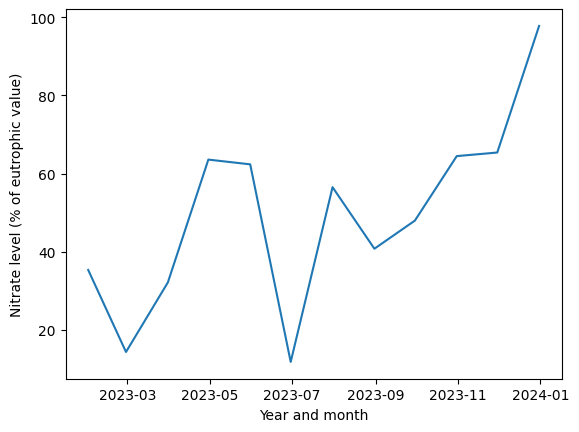

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

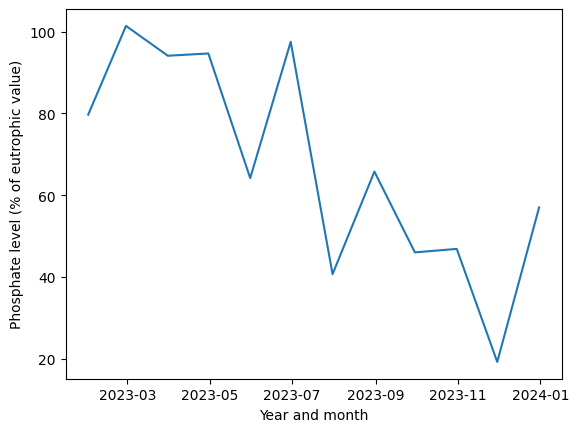

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

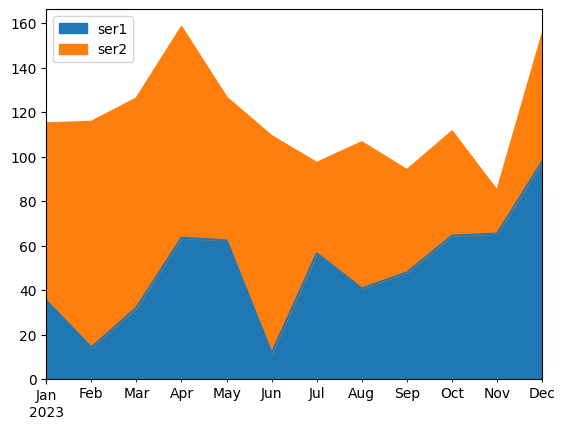

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

## Weekly Graph Question

### Advantages of Using an Area Plot

One advantage of using an area plot to display nitrate and phosphate levels is that it allows the viewer to easily compare the overall magnitude and combined trends of the two variables over time. The filled areas make it clear how the values change across the months and help highlight periods where both variables are relatively high or low. Area plots can also emphasize the cumulative visual effect of the variables, which may help illustrate overall environmental conditions.

### Disadvantages of Using an Area Plot

A disadvantage of using an area plot is that it can make it difficult to clearly distinguish the individual values of each variable, especially when the areas overlap. The filled regions may obscure the lower series and make it harder to interpret exact values or subtle changes. In addition, the visual stacking can sometimes give the impression that the values are additive when they may actually represent separate measurements.

### Improvements to the Graph

Several adjustments could improve the clarity of the graph:

- Use distinct colors with transparency so both variables remain visible.
- Add clear labels and a legend to distinguish nitrate and phosphate levels.
- Reduce unnecessary visual clutter by simplifying the background and gridlines.
- Consider plotting the two variables as separate line charts if the goal is to compare trends more precisely.
- Highlight important months or unusual spikes to guide the viewer's attention to meaningful patterns.

Overall, while the area plot effectively shows general trends over time, separating the variables into two line graphs may improve readability and make comparisons easier.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [5]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("datasetengineer/logistics-and-supply-chain-dataset")

print(os.listdir(path))

df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))

df.head()

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['dynamic_supply_chain_logistics_dataset.csv']


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


In [6]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  str    
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs               

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,...,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation
count,32065.000000,32065.000000,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,3.206500e+04,32065.000000,3.206500e+04,...,32065.000000,32065.000000,3.206500e+04,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,32065.000000,32065.000000
mean,38.023589,-90.116648,8.011735,2.893068,4.991493e+00,2.992547e+02,2.291669,3.026954e-01,0.600740,4.976082e-01,...,6022.001286,0.044792,2.972816e-01,7.001144,2.296448,4.983913e-01,6.008723e-01,0.803656,0.699077,5.177648
std,6.917909,17.369244,4.264960,2.274044,3.532048e+00,3.234435e+02,1.554202,3.259146e-01,0.345672,3.532853e-01,...,3427.638017,14.187486,3.216115e-01,3.236328,1.555932,3.541589e-01,3.458101e-01,0.279185,0.324514,4.157988
min,30.000000,-119.999998,5.000000,-1.999993,1.091633e-09,1.322210e-12,0.500000,4.565769e-16,0.000001,4.536949e-09,...,100.002966,-10.000000,7.255415e-19,0.000050,0.500000,4.043927e-09,3.269508e-07,0.000048,0.000003,-1.999998
25%,31.280550,-106.253913,5.019984,1.185744,1.474720e+00,1.605163e+01,0.774798,1.710828e-02,0.277096,1.440135e-01,...,2822.607616,-9.931074,1.678269e-02,4.593407,0.776166,1.443567e-01,2.783148e-01,0.693739,0.456009,1.269197
50%,36.413820,-86.293414,5.636036,3.882059,4.981244e+00,1.572880e+02,1.917121,1.595151e-01,0.680553,4.961781e-01,...,6785.123209,-7.858681,1.549760e-01,8.385605,1.938273,4.988468e-01,6.831130e-01,0.958128,0.839599,6.113662
75%,44.453655,-73.079367,9.669944,4.884355,8.534902e+00,5.405980e+02,3.734188,5.535954e-01,0.938160,8.498226e-01,...,9374.252913,6.024012,5.405408e-01,9.836152,3.750817,8.510762e-01,9.372889e-01,0.998746,0.982391,9.249206
max,50.000000,-70.000000,19.999875,5.000000,9.999999e+00,9.999993e+02,5.000000,9.999995e-01,1.000000,1.000000e+00,...,10000.000000,39.999886,1.000000e+00,10.000000,5.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,10.000000


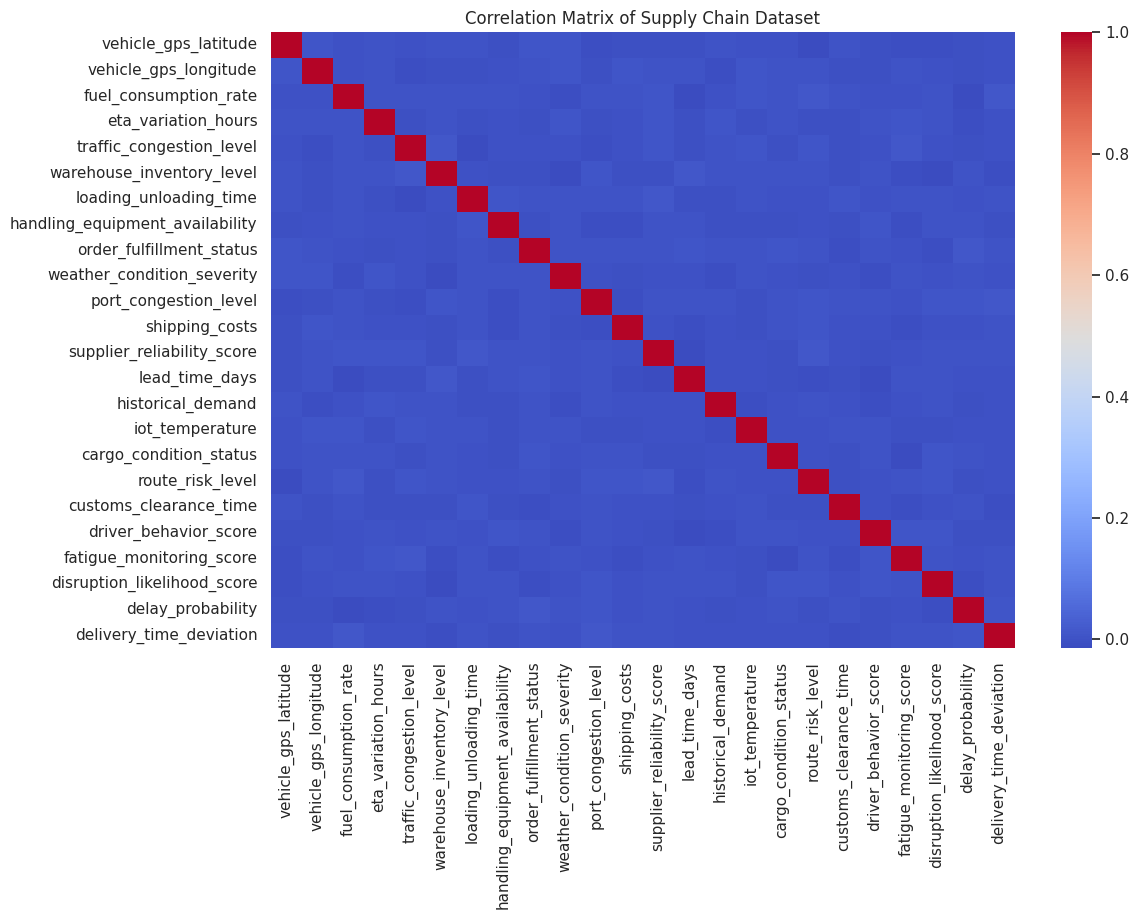

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Matrix of Supply Chain Dataset")
plt.show()

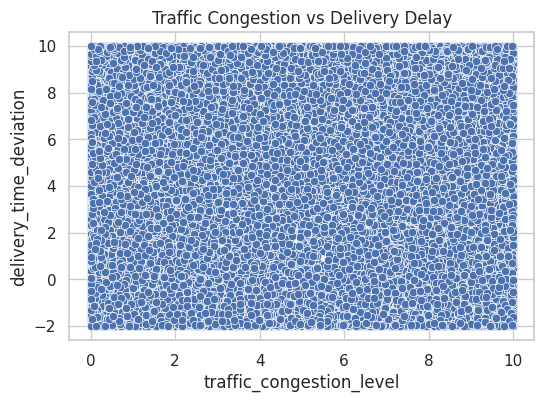

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="traffic_congestion_level",
    y="delivery_time_deviation"
)

plt.title("Traffic Congestion vs Delivery Delay")
plt.show()

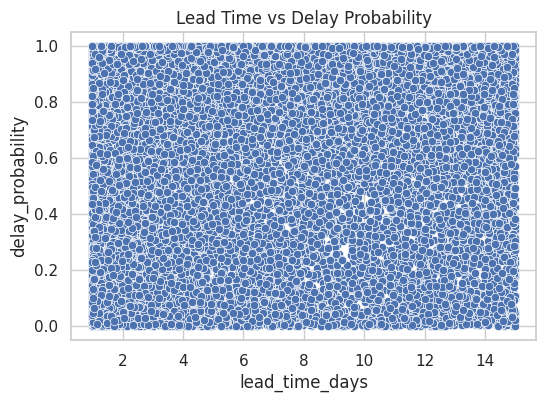

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="lead_time_days",
    y="delay_probability"
)

plt.title("Lead Time vs Delay Probability")
plt.show()

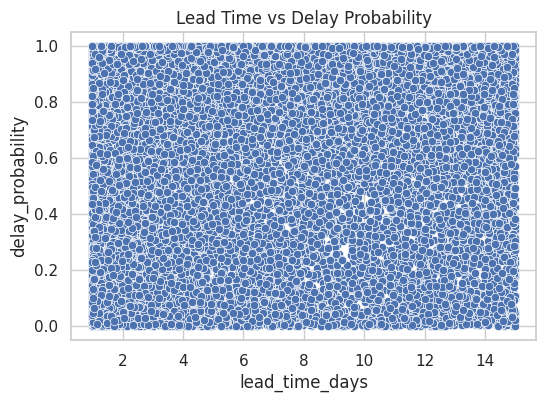

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="lead_time_days",
    y="delay_probability"
)

plt.title("Lead Time vs Delay Probability")
plt.show()

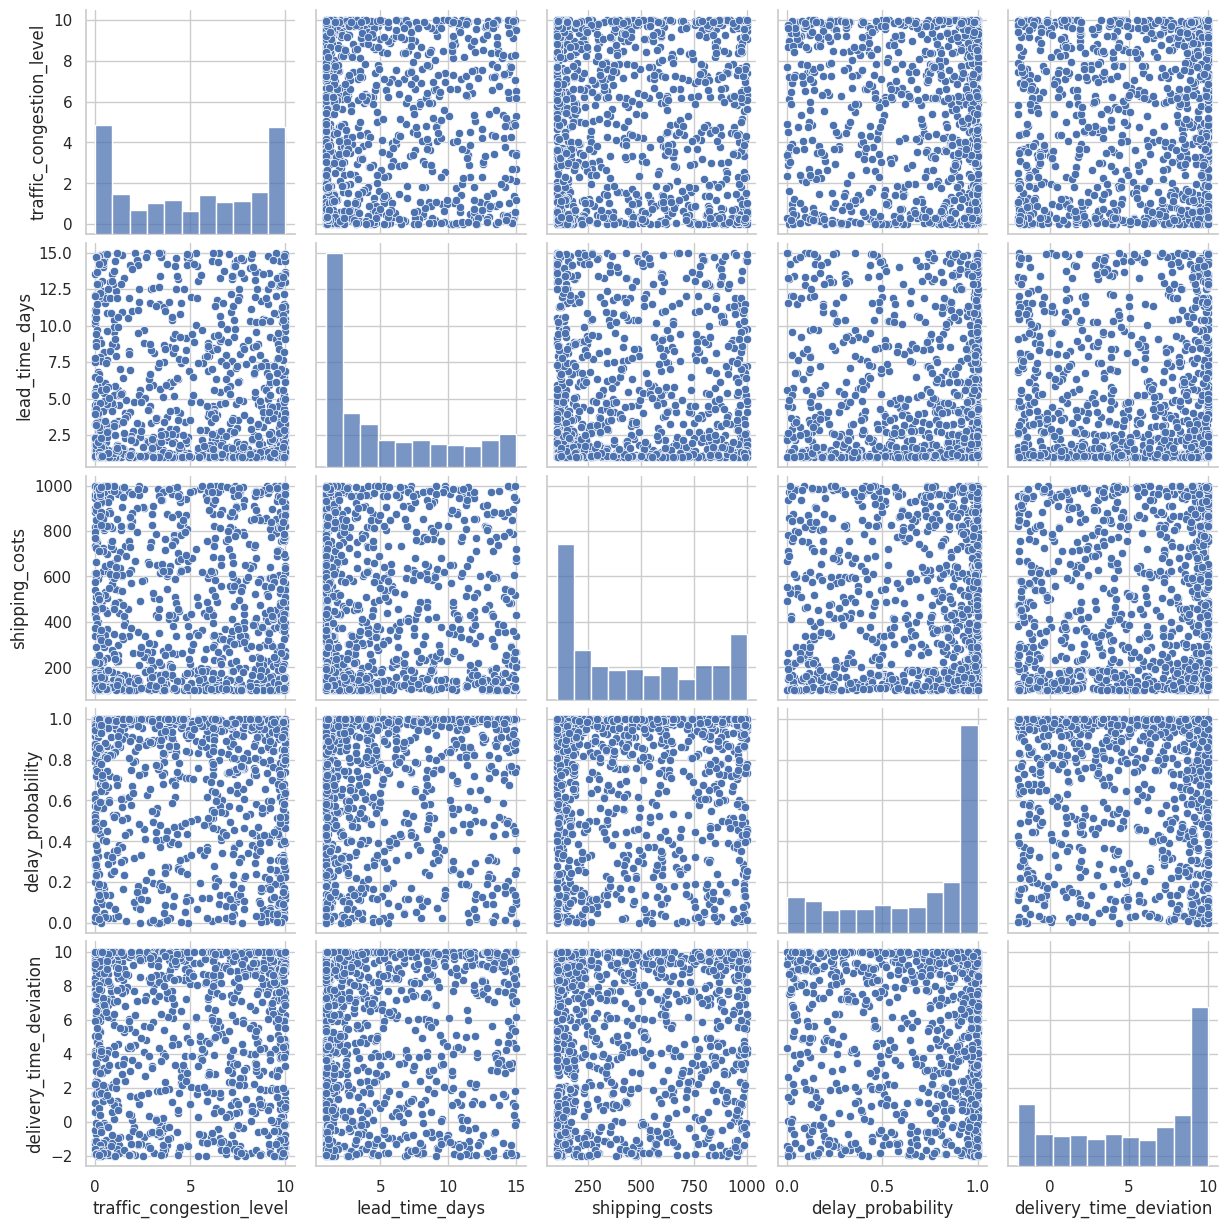

In [12]:
cols = [
    "traffic_congestion_level",
    "lead_time_days",
    "shipping_costs",
    "delay_probability",
    "delivery_time_deviation"
]

sns.pairplot(df[cols].sample(1000))
plt.show()

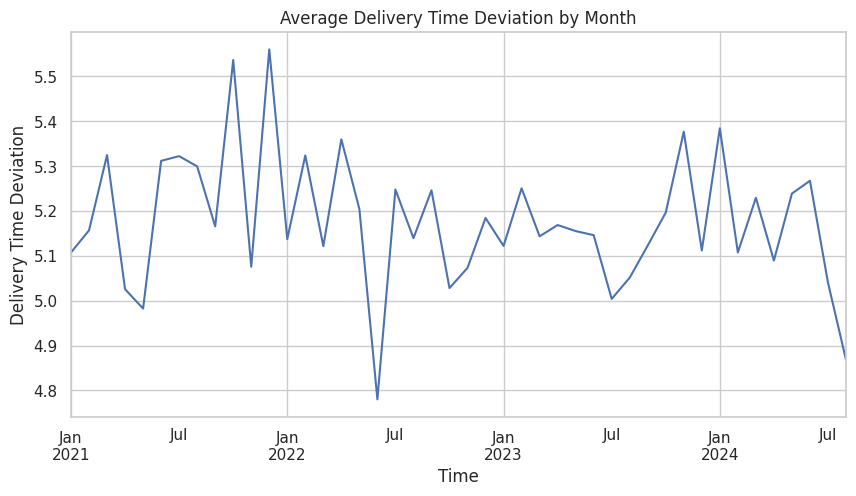

In [16]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

monthly_delay = df.resample("ME", on="timestamp")["delivery_time_deviation"].mean()

plt.figure(figsize=(10,5))
monthly_delay.plot()

plt.title("Average Delivery Time Deviation by Month")
plt.xlabel("Time")
plt.ylabel("Delivery Time Deviation")

plt.show()

<Figure size 1000x500 with 0 Axes>

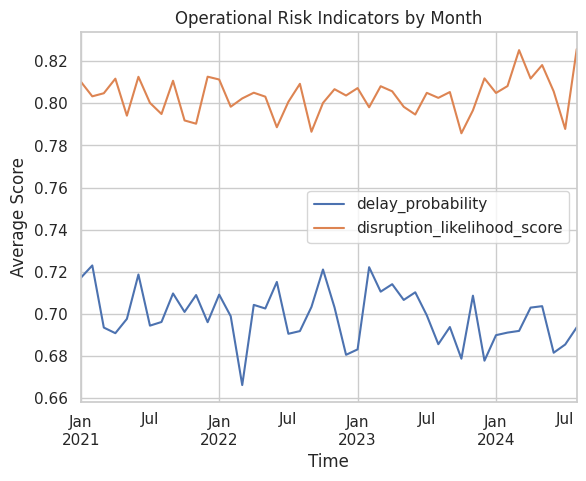

In [18]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

monthly = df.resample("ME", on="timestamp")[[
    "delay_probability",
    "disruption_likelihood_score"
]].mean()

plt.figure(figsize=(10,5))
monthly.plot()

plt.title("Operational Risk Indicators by Month")
plt.xlabel("Time")
plt.ylabel("Average Score")

plt.show()

## Conclusions

The exploratory analysis suggests that the dataset contains several operational indicators related to logistics and supply chain performance. Based on the correlation matrix, scatterplots, and pairplots, most variables show very weak correlations with each other. This indicates that the features represent different operational factors rather than redundant measurements. The data therefore appear usable for analysis because each variable contributes unique information about supply chain conditions.

### Outliers
There do not appear to be strong outliers in most of the variables. The scatterplots show that the data points are generally distributed within consistent ranges, although there are occasional extreme values in variables such as shipping costs or delivery time deviation. These may represent unusual operational events or disruptions but they are not frequent enough to dominate the dataset.

### Correlation Between Variables
The correlation analysis shows that almost no variables are highly correlated with each other. Most correlation values are very close to zero. This suggests that the dataset does not contain redundant variables and that each feature measures a different aspect of supply chain operations.

### Trends Over Time
The time-series analysis shows that delivery time deviation and operational risk indicators fluctuate slightly over time but remain within relatively stable ranges. There is no strong upward or downward trend in these variables across the observed time period. This suggests that the operational conditions represented in the dataset remain relatively consistent over time, and there is no evidence of strong data drift that would invalidate comparisons between different periods.

### Possible Confounding Variables
It is possible that there are confounding variables affecting some of the relationships in the data. For example, factors such as geographic location, seasonal demand patterns, infrastructure quality, or transportation policies could influence delivery times and operational risks. These factors may not be directly included in the dataset but could still affect the relationships between the observed variables.

### Overall Assessment
Overall, the dataset appears suitable for exploratory analysis and could potentially be used for predictive modeling or operational risk analysis in supply chain management.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

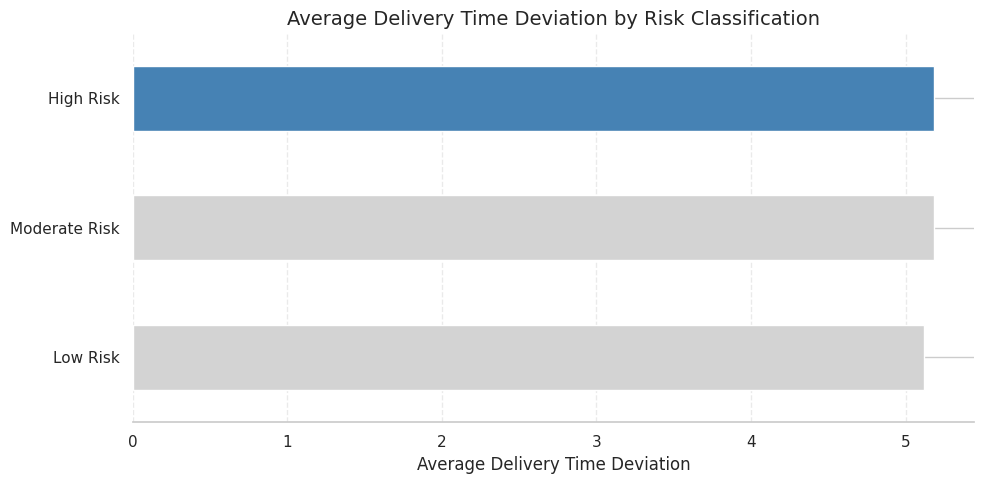

In [19]:

# Calculate average delivery time deviation by risk classification
story_data = (
    df.groupby("risk_classification")["delivery_time_deviation"]
    .mean()
    .sort_values()
)

# Create colors: gray for all, blue for the highest
colors = ["lightgray"] * len(story_data)
colors[-1] = "steelblue"

plt.figure(figsize=(10, 5))
story_data.plot(kind="barh", color=colors)

plt.title("Average Delivery Time Deviation by Risk Classification", fontsize=14)
plt.xlabel("Average Delivery Time Deviation")
plt.ylabel("")

# Remove extra chart junk
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()